# 06. Model Design — EDA-Driven Approach (2026-03-08)

## Recruit Restaurant Visitor Forecasting

**Goal**: EDAの発見事項から論理的にモデルを設計する。結果ありきではなく、「なぜこのモデルか」を順を追って記録する。

### Notebook Flow
1. EDA Recap → 問題の特性整理
2. 問題特性からモデル選定基準を導出
3. ベースライン構築（最もシンプルなモデル = 下限スコア）
4. EDA発見に基づく特徴量設計
5. 候補モデルの系統的比較
6. ハイパーパラメータ調整
7. アンサンブル → 最終モデル → Submission

**評価指標**: RMSLE（log1p空間でのRMSE）

---
## 1. EDA Findings Recap → 問題の特性整理

### EDAで判明した主要事実

| # | 発見事項 | モデル設計への影響 |
|---|---------|------------------|
| 1 | 強い週次周期（金土ピーク） | DOW特徴量必須、lag-7が最重要ラグ |
| 2 | 12月急増（忘年会シーズン） | 月別効果が大きい → month特徴量 |
| 3 | 店舗ごとにデータ開始日が大幅に異なる | 短い履歴の店舗ではlag/rolling特徴量が欠損 → 代替値が必要 |
| 4 | 定休日パターンが存在（火・水に多い） | 定休日の店舗は予測不要の可能性。ただしテストデータに含まれるか要確認 |
| 5 | 目的変数は対数正規分布 | log1p変換 → RMSLE = log空間のRMSE |
| 6 | テスト期間にGW含む（学習データに1回のみ） | **最大のリスク**: GW挙動の学習データが極めて少ない |
| 7 | ジャンルにより祝日効果が正反対 | genre × holiday交互作用が必要 |
| 8 | 祝日前日効果 | is_before_holiday特徴量 |
| 9 | 予約データは~30%のstore-dayのみカバー | 予約特徴量は有用だが欠損処理が鍵 |
| 10 | テスト店舗はすべてtrainに存在 | cold start問題なし → store-level特徴量を活用可能 |
| 11 | ACF: lag-7が突出、lag-1も有意 | 時系列ラグ特徴量の優先順位: lag-7 > lag-14 > lag-1 |

### この問題の特性

```
問題タイプ:     多店舗の時系列回帰（829店舗 × 39日）
データ構造:     パネルデータ（entity × time）
目的変数:       visitors（正整数、対数正規）
テスト期間:     2017-04-23 ~ 2017-05-31（39日先まで）
主な駆動要因:   曜日 >> 月 > 店舗固有水準 > 祝日 > 予約
最大リスク:     GW（テスト期間内、学習データで1回のみ観測）
```

---
## 2. 問題特性 → モデル選定基準の導出

### 2a. なぜ「テーブル系 GBDT」が第一候補か

| 問題の特性 | GBDT が適する理由 | 時系列専用モデル(Prophet/ARIMA)の問題点 |
|-----------|------------------|--------------------------------------|
| 829店舗のパネルデータ | 1モデルで全店舗を学習可能（cross-learning） | 店舗ごとに個別モデル → 829回学習、GW1回分の学習データが不足 |
| カテゴリカル特徴量（genre, area）が多い | ネイティブにカテゴリカルを扱える（CatBoost/LightGBM） | カテゴリカル特徴量を直接組み込めない |
| 予約データ等の外部特徴量 | 任意の特徴量を追加可能 | 外部リグレッサとして追加可能だが制約が多い |
| テスト期間が39日（長期） | ラグ特徴量を再帰的に使わず、静的特徴量で対応可能 | 再帰予測 → 誤差蓄積のリスク |
| GWの学習サンプルが1回分 | 他の祝日やgenre×holiday交互作用で「汎化」できる | 店舗単位ではGWサンプル1点 → 過学習かノイズ |

### 2b. GBDT候補の比較

| | LightGBM | XGBoost | CatBoost |
|---|---------|---------|----------|
| 速度 | 最速 | 中速 | 遅い |
| カテゴリカル処理 | ネイティブ対応 | ラベルエンコ必要 | **最も優秀**（ordered TS） |
| 過学習耐性 | 普通 | 良い（正則化豊富） | **最も強い** |
| 欠損値処理 | ネイティブ | ネイティブ | ネイティブ |
| 実績（本コンペ上位） | 8th, 3rd place使用 | 多数使用 | 情報少ない |

**結論**: 3モデルすべてを同条件で比較し、最終的にアンサンブル。

### 2c. なぜ Random Forest は外すか

EDAからの判断:
- **lag特徴量の重要性**: lag-7, rolling_mean等の連続値特徴量が支配的 → 分岐ベースのRFはGBDTより非効率
- **交互作用の深さ**: genre×holiday×DOW等の多段交互作用 → boosting（逐次残差学習）の方が効率的
- **速度**: 大きな探索空間のチューニングが必要 → RFはGBDTより遅い

ただし、多様性のためアンサンブルの一員として後で検討する余地はある。

### 2d. バリデーション戦略（EDAのSection 11から）

```
Fold 1: ~2016-04-22 → Val: 2016-04-23 ~ 2016-05-31 (GW含む ★最重要)
Fold 2: ~2016-07-15 → Val: 2016-07-16 ~ 2016-08-23
Fold 3: ~2016-10-14 → Val: 2016-10-15 ~ 2016-11-22
Fold 4: ~2016-12-15 → Val: 2016-12-16 ~ 2017-01-23
Fold 5: ~2017-03-14 → Val: 2017-03-15 ~ 2017-04-22 (テスト直前)
```

**CVスコア = 5 foldの平均RMSLE**（Fold 1の重みを特に注視）

---
## 3. ベースライン構築

**ベースラインの意義**: モデルの下限スコアを確定する。すべての改良はこのスコアを上回る必要がある。

**アプローチ**: 店舗 × 曜日 の中央値（EDAで曜日が最大の駆動要因と判明しているため）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

INPUT_DIR = Path('../input')
OUTPUT_DIR = Path('../output')

# ── Load data ──
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])
submission = pd.read_csv(INPUT_DIR / 'sample_submission.csv')

# Parse submission
submission['air_store_id'] = submission['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
submission['visit_date'] = pd.to_datetime(submission['id'].apply(lambda x: x.split('_')[-1]))

# Basic derived columns
air_visit['dow'] = air_visit['visit_date'].dt.dayofweek
air_visit['log_visitors'] = np.log1p(air_visit['visitors'])

def rmsle(y_true, y_pred):
    """RMSLE = RMSE in log1p space."""
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.maximum(y_pred, 0))))

# ── Validation folds (from EDA) ──
val_folds = [
    ('2016-04-23', '2016-05-31'),  # Fold 1: GW
    ('2016-07-16', '2016-08-23'),  # Fold 2: Summer
    ('2016-10-15', '2016-11-22'),  # Fold 3: Autumn
    ('2016-12-16', '2017-01-23'),  # Fold 4: Year-end
    ('2017-03-15', '2017-04-22'),  # Fold 5: Pre-test
]

print(f'Data loaded. air_visit: {air_visit.shape}, air_store: {air_store.shape}')
print(f'Submission: {submission.shape} ({submission["visit_date"].min().date()} ~ {submission["visit_date"].max().date()})')
print(f'Validation: {len(val_folds)} folds')

Data loaded. air_visit: (252108, 5), air_store: (829, 5)
Submission: (32019, 4) (2017-04-23 ~ 2017-05-31)
Validation: 5 folds


In [2]:
# ── Baseline: store × DOW median ──
# EDAで曜日が最大の駆動要因であることが判明 → 最もシンプルな意味のあるベースライン

baseline_scores = []
print('=== Baseline: store × DOW median ===\n')

for fold_idx, (val_start, val_end) in enumerate(val_folds):
    val_start, val_end = pd.Timestamp(val_start), pd.Timestamp(val_end)
    
    train = air_visit[air_visit['visit_date'] < val_start]
    val = air_visit[(air_visit['visit_date'] >= val_start) & (air_visit['visit_date'] <= val_end)]
    
    # store × DOW median from training data
    store_dow_median = train.groupby(['air_store_id', 'dow'])['visitors'].median()
    
    # Fallback: store median (DOWが不足する場合)
    store_median = train.groupby('air_store_id')['visitors'].median()
    
    # Global fallback
    global_median = train['visitors'].median()
    
    # Predict
    val = val.copy()
    val['pred'] = val.apply(
        lambda r: store_dow_median.get((r['air_store_id'], r['dow']),
                  store_median.get(r['air_store_id'], global_median)), axis=1
    )
    
    score = rmsle(val['visitors'], val['pred'])
    baseline_scores.append(score)
    print(f'  Fold {fold_idx+1}: RMSLE = {score:.4f}  (val: {val_start.date()} ~ {val_end.date()}, n={len(val):,})')

mean_baseline = np.mean(baseline_scores)
print(f'\n  Mean RMSLE = {mean_baseline:.4f} (±{np.std(baseline_scores):.4f})')
print(f'\n→ これがベースライン。すべてのモデルはこのスコアを下回る（= 改善する）必要がある。')
print(f'→ Fold間の分散にも注目: 分散が大きい = 特殊期間への対応が不十分')

=== Baseline: store × DOW median ===



  Fold 1: RMSLE = 0.5913  (val: 2016-04-23 ~ 2016-05-31, n=10,336)


  Fold 2: RMSLE = 0.6215  (val: 2016-07-16 ~ 2016-08-23, n=26,084)


  Fold 3: RMSLE = 0.5708  (val: 2016-10-15 ~ 2016-11-22, n=27,168)


  Fold 4: RMSLE = 0.6164  (val: 2016-12-16 ~ 2017-01-23, n=24,817)


  Fold 5: RMSLE = 0.5541  (val: 2017-03-15 ~ 2017-04-22, n=28,031)

  Mean RMSLE = 0.5908 (±0.0259)

→ これがベースライン。すべてのモデルはこのスコアを下回る（= 改善する）必要がある。
→ Fold間の分散にも注目: 分散が大きい = 特殊期間への対応が不十分


---
## 4. EDA発見に基づく特徴量設計

各特徴量がEDAのどの発見事項に基づくかを明記する。

| 特徴量グループ | EDA根拠 | 期待される効果 |
|--------------|---------|-------------|
| 曜日・月・年 | Sec 5: 週次周期、月別変動 | ベースラインの改善 |
| 祝日関連 | Sec 7: 祝日前日効果、ジャンル別祝日反応 | GW予測の精度向上 |
| 特殊期間フラグ | Sec 7: GW/正月/お盆/年末は一律holiday_flgでは不十分 | 特殊期間の粒度向上 |
| ラグ特徴量 | Sec 6: ACFでlag-7が突出 | 直近の来客傾向を反映 |
| ローリング統計量 | Sec 6: 7/14/28日窓 | 短期・中期のトレンド把握 |
| 店舗レベル統計量 | Sec 4: 店舗間の来客水準が大幅に異なる | 店舗固有の基準値 |
| ジャンル・エリア | Sec 8: ジャンルにより来客パターンが異なる | cross-learning効果 |
| 予約データ | Sec 9: 相関は中程度だが有用 | テスト期間でも利用可能な先行指標 |

In [3]:
# ══════════════════════════════════════════════════════════════
# 4a. 特徴量生成パイプライン
# ══════════════════════════════════════════════════════════════

# ── Step 1: date_info 拡張（祝日前日・翌日・特殊期間フラグ） ──
# EDA Sec 7: holiday_flg だけでは不十分

date_feat = date_info.rename(columns={'calendar_date': 'visit_date'}).copy()
date_feat = date_feat.sort_values('visit_date').reset_index(drop=True)

# 祝日前日・翌日（EDA Sec 7c: 前日効果あり）
date_feat['holiday_tomorrow'] = date_feat['holiday_flg'].shift(-1).fillna(0).astype(int)
date_feat['holiday_yesterday'] = date_feat['holiday_flg'].shift(1).fillna(0).astype(int)
date_feat['is_before_holiday'] = ((date_feat['holiday_flg'] == 0) & (date_feat['holiday_tomorrow'] == 1)).astype(int)
date_feat['is_after_holiday'] = ((date_feat['holiday_flg'] == 0) & (date_feat['holiday_yesterday'] == 1)).astype(int)

# 特殊期間フラグ（EDA Sec 7: 祝日を種類別に区別）
def get_special_period(date):
    m, d = date.month, date.day
    if m == 1 and d <= 3: return 'new_year'
    if m == 4 and d >= 29: return 'golden_week'
    if m == 5 and d <= 7: return 'golden_week'
    if m == 8 and 13 <= d <= 16: return 'obon'
    if m == 12 and d >= 20: return 'year_end'
    return 'normal'

date_feat['special_period'] = date_feat['visit_date'].apply(get_special_period)

# 連休の長さ（連続する祝日の長さ）
# holiday_flg の連続ブロックの長さを計算
holiday_blocks = (date_feat['holiday_flg'] != date_feat['holiday_flg'].shift()).cumsum()
block_sizes = date_feat.groupby(holiday_blocks)['holiday_flg'].transform('sum')
date_feat['holiday_streak'] = (block_sizes * date_feat['holiday_flg']).astype(int)

print('Date features created:')
print(f'  Columns: {list(date_feat.columns)}')
print(f'  Special periods: {date_feat["special_period"].value_counts().to_dict()}')

Date features created:
  Columns: ['visit_date', 'day_of_week', 'holiday_flg', 'holiday_tomorrow', 'holiday_yesterday', 'is_before_holiday', 'is_after_holiday', 'special_period', 'holiday_streak']
  Special periods: {'normal': 477, 'golden_week': 18, 'year_end': 12, 'new_year': 6, 'obon': 4}


In [4]:
# ── Step 2: 予約データ集約（EDA Sec 9） ──
# テスト期間でも利用可能な先行指標として予約データを集約

# Air reservations
air_reserve['visit_date'] = air_reserve['visit_datetime'].dt.floor('D')
air_res_agg = air_reserve.groupby(['air_store_id', 'visit_date']).agg(
    air_res_visitors=('reserve_visitors', 'sum'),
    air_res_count=('reserve_visitors', 'count'),
).reset_index()

# HPG reservations (via store_relation)
hpg_reserve['visit_date'] = hpg_reserve['visit_datetime'].dt.floor('D')
hpg_res_mapped = hpg_reserve.merge(store_relation, on='hpg_store_id', how='inner')
hpg_res_agg = hpg_res_mapped.groupby(['air_store_id', 'visit_date']).agg(
    hpg_res_visitors=('reserve_visitors', 'sum'),
    hpg_res_count=('reserve_visitors', 'count'),
).reset_index()

print(f'Air reservation aggregated: {air_res_agg.shape}')
print(f'HPG reservation aggregated (mapped): {hpg_res_agg.shape}')

Air reservation aggregated: (29830, 4)
HPG reservation aggregated (mapped): (18620, 4)


In [5]:
# ── Step 3: 統合特徴量生成関数 ──
# この関数はバリデーションと最終提出の両方で使用する
# 重要: lag/rolling特徴量の計算では学習データのみ使用（リーク防止）

def build_features(train_df, target_dates_df, air_store_info, date_features, 
                   air_res, hpg_res, compute_target=True):
    """
    EDA発見事項に基づく特徴量セットを構築する。
    
    Parameters:
        train_df: air_visit_data (学習に使える過去データ)
        target_dates_df: 予測対象の (air_store_id, visit_date) DataFrame
        air_store_info: 店舗マスタ
        date_features: 日付特徴量
        air_res, hpg_res: 予約集約データ
        compute_target: Trueならtarget列を付与（バリデーション用）
    """
    df = target_dates_df[['air_store_id', 'visit_date']].copy()
    
    # ── 時間特徴量（EDA Sec 5: DOW, month） ──
    df['dow'] = df['visit_date'].dt.dayofweek
    df['month'] = df['visit_date'].dt.month
    df['day'] = df['visit_date'].dt.day
    df['week_of_year'] = df['visit_date'].dt.isocalendar().week.astype(int)
    
    # ── 日付特徴量マージ（祝日・特殊期間） ──
    df = df.merge(date_features[['visit_date', 'holiday_flg', 'is_before_holiday', 
                                  'is_after_holiday', 'special_period', 'holiday_streak']], 
                  on='visit_date', how='left')
    
    # ── 店舗マスタ特徴量（EDA Sec 8: genre, area） ──
    df = df.merge(air_store_info[['air_store_id', 'air_genre_name', 'air_area_name',
                                   'latitude', 'longitude']], on='air_store_id', how='left')
    df['prefecture'] = df['air_area_name'].apply(lambda x: x.split(' ')[0] if pd.notna(x) else 'unknown')
    
    # ── 店舗レベル統計量（EDA Sec 4: 店舗間の来客水準差が大きい） ──
    store_stats = train_df.groupby('air_store_id')['visitors'].agg(
        store_mean='mean', store_median='median', store_std='std',
        store_min='min', store_max='max', store_count='count'
    )
    df = df.merge(store_stats, on='air_store_id', how='left')
    
    # ── 店舗×曜日 統計量（ベースラインで最も効いた特徴量） ──
    store_dow_stats = train_df.groupby(['air_store_id', 'dow'])['visitors'].agg(
        store_dow_mean='mean', store_dow_median='median', store_dow_std='std',
        store_dow_count='count'
    )
    df = df.merge(store_dow_stats, on=['air_store_id', 'dow'], how='left')
    
    # ── ジャンル×曜日 統計量（EDA Sec 8: ジャンルにより曜日パターンが異なる） ──
    train_with_genre = train_df.merge(air_store_info[['air_store_id', 'air_genre_name']], on='air_store_id')
    genre_dow_stats = train_with_genre.groupby(['air_genre_name', 'dow'])['visitors'].agg(
        genre_dow_mean='mean', genre_dow_median='median'
    )
    df = df.merge(genre_dow_stats, on=['air_genre_name', 'dow'], how='left')
    
    # ── ラグ特徴量（EDA Sec 6: ACF → lag-7が突出） ──
    train_pivot = train_df.pivot_table(index='visit_date', columns='air_store_id', 
                                        values='visitors', aggfunc='first')
    for lag in [7, 14, 21, 28, 35]:
        lag_vals = train_pivot.shift(lag).stack().reset_index()
        lag_vals.columns = ['visit_date', 'air_store_id', f'lag_{lag}']
        df = df.merge(lag_vals, on=['air_store_id', 'visit_date'], how='left')
    
    # ── ローリング統計量（EDA Sec 6: 短期・中期のトレンド） ──
    for window in [7, 14, 28]:
        roll_mean = train_pivot.rolling(window, min_periods=1).mean().stack().reset_index()
        roll_mean.columns = ['visit_date', 'air_store_id', f'rolling_mean_{window}']
        # shift by 1 to prevent leakage (use data up to yesterday)
        roll_mean['visit_date'] = roll_mean['visit_date'] + pd.Timedelta(days=1)
        df = df.merge(roll_mean, on=['air_store_id', 'visit_date'], how='left')
    
    # ── 予約特徴量（EDA Sec 9: カバー率低いが相関あり） ──
    df = df.merge(air_res, on=['air_store_id', 'visit_date'], how='left')
    df = df.merge(hpg_res, on=['air_store_id', 'visit_date'], how='left')
    df['total_res_visitors'] = df['air_res_visitors'].fillna(0) + df['hpg_res_visitors'].fillna(0)
    df['total_res_count'] = df['air_res_count'].fillna(0) + df['hpg_res_count'].fillna(0)
    df['has_reservation'] = (df['total_res_visitors'] > 0).astype(int)
    
    # ── Target（バリデーション用） ──
    # target_dates_df から取得（train_dfではなく、予測対象データにvisitorsが含まれる場合）
    if compute_target:
        if 'visitors' in target_dates_df.columns:
            df = df.merge(target_dates_df[['air_store_id', 'visit_date', 'visitors']],
                          on=['air_store_id', 'visit_date'], how='left')
        else:
            df['visitors'] = np.nan
    
    return df

print('Feature engineering pipeline defined.')
print(f'Key design decisions:')
print(f'  - Lag features: lag_7/14/21/28/35 (ACF-based)')
print(f'  - Rolling windows: 7/14/28 days (shifted by 1 day for leakage prevention)')
print(f'  - Store-level stats: mean/median/std/count (from training data only)')
print(f'  - Holiday features: before/after/special_period/streak')

Feature engineering pipeline defined.
Key design decisions:
  - Lag features: lag_7/14/21/28/35 (ACF-based)
  - Rolling windows: 7/14/28 days (shifted by 1 day for leakage prevention)
  - Store-level stats: mean/median/std/count (from training data only)
  - Holiday features: before/after/special_period/streak


In [6]:
# ── Step 4: 特徴量カラムの定義 ──
# モデルに投入する特徴量を明示的にリスト化

CATEGORICAL_FEATURES = ['air_genre_name', 'air_area_name', 'prefecture', 'special_period']
NUMERIC_FEATURES = [
    # 時間
    'dow', 'month', 'day', 'week_of_year',
    # 祝日
    'holiday_flg', 'is_before_holiday', 'is_after_holiday', 'holiday_streak',
    # 店舗統計量
    'store_mean', 'store_median', 'store_std', 'store_min', 'store_max', 'store_count',
    # 店舗×曜日
    'store_dow_mean', 'store_dow_median', 'store_dow_std', 'store_dow_count',
    # ジャンル×曜日
    'genre_dow_mean', 'genre_dow_median',
    # ラグ
    'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35',
    # ローリング
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28',
    # 予約
    'air_res_visitors', 'air_res_count', 'hpg_res_visitors', 'hpg_res_count',
    'total_res_visitors', 'total_res_count', 'has_reservation',
    # 位置
    'latitude', 'longitude',
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f'Total features: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)')

Total features: 41 (37 numeric + 4 categorical)


---
## 5. 候補モデルの系統的比較

### 比較方針
- **同一特徴量セット**で3モデルを比較（条件を揃える）
- **同一バリデーション**（5-fold TimeSeriesSplit）
- **デフォルトに近いパラメータ**で初回比較 → 調整は次セクション
- 目的変数: `log1p(visitors)` → 予測後に `expm1` で逆変換
- カテゴリカル特徴量: LightGBM/CatBoostはネイティブ対応、XGBoostはラベルエンコーディング

In [7]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
from sklearn.preprocessing import LabelEncoder
import time

# ── 5-Fold CV with feature building ──
def run_cv(model_name, model_fn, air_visit_df, val_folds, air_store_info, 
           date_features, air_res, hpg_res, features, cat_features):
    """
    Run time-series CV for a given model.
    Returns fold scores and total predictions for analysis.
    """
    fold_scores = []
    fold_predictions = []
    total_time = 0
    
    for fold_idx, (val_start, val_end) in enumerate(val_folds):
        val_start_ts, val_end_ts = pd.Timestamp(val_start), pd.Timestamp(val_end)
        
        # Split: train = everything before val_start
        train_data = air_visit_df[air_visit_df['visit_date'] < val_start_ts].copy()
        val_data = air_visit_df[(air_visit_df['visit_date'] >= val_start_ts) & 
                                (air_visit_df['visit_date'] <= val_end_ts)].copy()
        
        if len(val_data) == 0 or len(train_data) == 0:
            continue
        
        # Build features
        train_feat = build_features(train_data, train_data, air_store_info, date_features,
                                     air_res, hpg_res, compute_target=True)
        val_feat = build_features(train_data, val_data, air_store_info, date_features,
                                   air_res, hpg_res, compute_target=True)
        
        # Drop rows with missing target
        train_feat = train_feat.dropna(subset=['visitors'])
        val_feat = val_feat.dropna(subset=['visitors'])
        
        if len(train_feat) == 0 or len(val_feat) == 0:
            continue
        
        X_train = train_feat[features].copy()
        y_train = np.log1p(train_feat['visitors'])
        X_val = val_feat[features].copy()
        y_val = val_feat['visitors']
        
        # Train and predict
        t0 = time.time()
        model = model_fn(X_train, y_train, X_val, np.log1p(y_val), cat_features)
        elapsed = time.time() - t0
        total_time += elapsed
        
        # Predict — use unify_categories for LightGBM to match training categories
        if model_name == 'LightGBM':
            _, X_val_pred = unify_categories(X_train, X_val, cat_features)
            y_pred = np.expm1(model.predict(X_val_pred))
        else:
            y_pred = np.expm1(model.predict(X_val))
        y_pred = np.maximum(y_pred, 0)
        
        score = rmsle(y_val.values, y_pred)
        fold_scores.append(score)
        fold_predictions.append(pd.DataFrame({
            'fold': fold_idx + 1,
            'actual': y_val.values,
            'predicted': y_pred,
            'visit_date': val_feat['visit_date'].values,
        }))
    
    return fold_scores, total_time, pd.concat(fold_predictions, ignore_index=True)

print('CV framework defined.')

CV framework defined.


In [8]:
# ── Model definitions (default-ish parameters) ──

# カテゴリカル特徴量のエンコーディング
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    all_vals = list(air_store[col.replace('air_', 'air_')].dropna().unique()) if col in ['air_genre_name', 'air_area_name'] else []
    if col == 'prefecture':
        all_vals = list(air_store['air_area_name'].apply(lambda x: x.split(' ')[0]).unique())
    elif col == 'special_period':
        all_vals = ['normal', 'new_year', 'golden_week', 'obon', 'year_end']
    le.fit(all_vals + ['unknown'])
    label_encoders[col] = le

def encode_categoricals(df, features, cat_features, label_encoders):
    """Label-encode categorical features (for XGBoost)."""
    df = df.copy()
    for col in cat_features:
        if col in df.columns:
            df[col] = df[col].fillna('unknown')
            df[col] = df[col].apply(lambda x: x if x in label_encoders[col].classes_ else 'unknown')
            df[col] = label_encoders[col].transform(df[col])
    return df

def unify_categories(X_train, X_val, cat_features):
    """Ensure train and val have same category levels for LightGBM."""
    X_tr = X_train.copy()
    X_v = X_val.copy()
    for col in cat_features:
        X_tr[col] = X_tr[col].fillna('unknown').astype(str)
        X_v[col] = X_v[col].fillna('unknown').astype(str)
        # Unify categories
        all_cats = sorted(set(X_tr[col].unique()) | set(X_v[col].unique()))
        cat_type = pd.CategoricalDtype(categories=all_cats)
        X_tr[col] = X_tr[col].astype(cat_type)
        X_v[col] = X_v[col].astype(cat_type)
    return X_tr, X_v

# ── LightGBM ──
def train_lgbm(X_train, y_train, X_val, y_val, cat_features):
    X_tr, X_v = unify_categories(X_train, X_val, cat_features)
    
    train_set = lgb.Dataset(X_tr, y_train, categorical_feature=cat_features)
    val_set = lgb.Dataset(X_v, y_val, categorical_feature=cat_features, reference=train_set)
    
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'min_child_samples': 20,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'verbose': -1,
        'seed': 42,
    }
    
    model = lgb.train(params, train_set, num_boost_round=1000,
                      valid_sets=[val_set],
                      callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    
    # Store pandas_categorical for prediction consistency
    model._pandas_categorical = model.pandas_categorical
    return model

# ── XGBoost ──
def train_xgb(X_train, y_train, X_val, y_val, cat_features):
    X_tr = encode_categoricals(X_train, ALL_FEATURES, cat_features, label_encoders)
    X_v = encode_categoricals(X_val, ALL_FEATURES, cat_features, label_encoders)
    
    dtrain = xgb.DMatrix(X_tr, y_train)
    dval = xgb.DMatrix(X_v, y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': 0.05,
        'max_depth': 6,
        'min_child_weight': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'lambda': 1.0,
        'alpha': 0.1,
        'seed': 42,
        'verbosity': 0,
    }
    
    model = xgb.train(params, dtrain, num_boost_round=1000,
                      evals=[(dval, 'val')],
                      early_stopping_rounds=50, verbose_eval=False)
    
    class XGBWrapper:
        def __init__(self, model, cat_features, label_encoders):
            self.model = model
            self.cat_features = cat_features
            self.label_encoders = label_encoders
        def predict(self, X):
            X_enc = encode_categoricals(X, ALL_FEATURES, self.cat_features, self.label_encoders)
            return self.model.predict(xgb.DMatrix(X_enc))
    
    return XGBWrapper(model, cat_features, label_encoders)

# ── CatBoost ──
def train_catboost(X_train, y_train, X_val, y_val, cat_features):
    X_tr = X_train.copy()
    X_v = X_val.copy()
    for col in cat_features:
        X_tr[col] = X_tr[col].fillna('unknown').astype(str)
        X_v[col] = X_v[col].fillna('unknown').astype(str)
    
    cat_indices = [list(X_tr.columns).index(c) for c in cat_features if c in X_tr.columns]
    
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
        cat_features=cat_indices,
    )
    
    model.fit(X_tr, y_train, eval_set=(X_v, y_val), verbose=0)
    return model

print('Model definitions ready: LightGBM, XGBoost, CatBoost')

Model definitions ready: LightGBM, XGBoost, CatBoost


In [9]:
# ── Run 3-model comparison ──
print('=' * 70)
print('5-FOLD TIME SERIES CV: MODEL COMPARISON')
print('=' * 70)

models = {
    'LightGBM': train_lgbm,
    'XGBoost': train_xgb,
    'CatBoost': train_catboost,
}

results = {}
all_preds = {}

for model_name, model_fn in models.items():
    print(f'\n--- {model_name} ---')
    scores, elapsed, preds = run_cv(
        model_name, model_fn, air_visit, val_folds,
        air_store, date_feat, air_res_agg, hpg_res_agg,
        ALL_FEATURES, CATEGORICAL_FEATURES
    )
    
    results[model_name] = {
        'scores': scores,
        'mean': np.mean(scores),
        'std': np.std(scores),
        'time': elapsed,
    }
    all_preds[model_name] = preds
    
    for i, s in enumerate(scores):
        print(f'  Fold {i+1}: {s:.4f}')
    print(f'  Mean: {np.mean(scores):.4f} (±{np.std(scores):.4f})  |  Time: {elapsed:.1f}s')

print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
print(f'\n{"Model":<15s} {"Mean RMSLE":>11s} {"±Std":>8s} {"Time":>8s} {"vs Baseline":>12s}')
print('-' * 56)
print(f'{"Baseline":<15s} {mean_baseline:>11.4f} {np.std(baseline_scores):>8.4f} {"N/A":>8s} {"---":>12s}')
for name, r in sorted(results.items(), key=lambda x: x[1]['mean']):
    improvement = mean_baseline - r['mean']
    print(f'{name:<15s} {r["mean"]:>11.4f} {r["std"]:>8.4f} {r["time"]:>7.1f}s {improvement:>+11.4f}')

5-FOLD TIME SERIES CV: MODEL COMPARISON

--- LightGBM ---


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[46]	valid_0's rmse: 0.584461


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[30]	valid_0's rmse: 0.596199


...

Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[69]	valid_0's rmse: 0.550545


  Fold 1: 0.5845
  Fold 2: 0.5962
  Fold 3: 0.5505
  Fold 4: 0.5802
  Fold 5: 0.5505
  Mean: 0.5724 (±0.0186)  |  Time: 6.9s

--- XGBoost ---


  Fold 1: 0.5848
  Fold 2: 0.6422
  Fold 3: 0.5449
  Fold 4: 0.5849
  Fold 5: 0.5673
  Mean: 0.5848 (±0.0322)  |  Time: 13.2s

--- CatBoost ---


  Fold 1: 0.5810
  Fold 2: 0.5942
  Fold 3: 0.5674
  Fold 4: 0.6060
  Fold 5: 0.6079
  Mean: 0.5913 (±0.0153)  |  Time: 16.6s

SUMMARY

Model            Mean RMSLE     ±Std     Time  vs Baseline
--------------------------------------------------------
Baseline             0.5908   0.0259      N/A          ---
LightGBM             0.5724   0.0186     6.9s     +0.0185
XGBoost              0.5848   0.0322    13.2s     +0.0060
CatBoost             0.5913   0.0153    16.6s     -0.0004


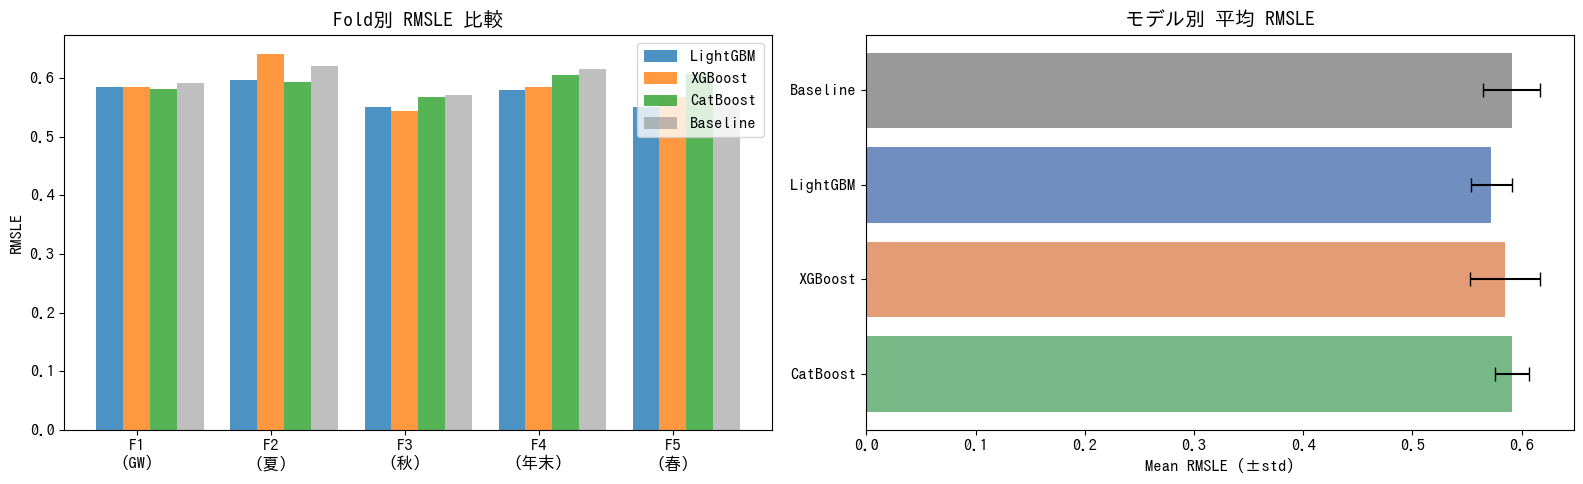


=== Fold別の考察 ===
Fold 1 (GW): テスト期間と同じ特殊期間を含む → ここのスコアが最も参考になる
Fold 4 (年末): 年末年始は独特の挙動 → スコアが高い場合、特殊期間対応が不十分


In [10]:
# ── Fold別スコアの可視化 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fold-by-fold comparison
fold_labels = [f'Fold {i+1}' for i in range(len(val_folds))]
x = np.arange(len(fold_labels))
width = 0.2

for i, (name, r) in enumerate(results.items()):
    axes[0].bar(x + i * width, r['scores'], width, label=name, alpha=0.8)
axes[0].bar(x + len(results) * width, baseline_scores, width, label='Baseline', alpha=0.5, color='gray')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['F1\n(GW)', 'F2\n(夏)', 'F3\n(秋)', 'F4\n(年末)', 'F5\n(春)'])
axes[0].set_ylabel('RMSLE')
axes[0].set_title('Fold別 RMSLE 比較')
axes[0].legend()
axes[0].set_ylim(0, None)

# Mean score comparison
model_names = ['Baseline'] + list(results.keys())
mean_scores = [mean_baseline] + [r['mean'] for r in results.values()]
std_scores = [np.std(baseline_scores)] + [r['std'] for r in results.values()]
colors = ['gray'] + ['#4C72B0', '#DD8452', '#55A868']

axes[1].barh(model_names, mean_scores, xerr=std_scores, color=colors[:len(model_names)], 
             alpha=0.8, capsize=5)
axes[1].set_xlabel('Mean RMSLE (±std)')
axes[1].set_title('モデル別 平均 RMSLE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# どのフォールドでスコアが悪いかを分析
print('\n=== Fold別の考察 ===')
print('Fold 1 (GW): テスト期間と同じ特殊期間を含む → ここのスコアが最も参考になる')
print('Fold 4 (年末): 年末年始は独特の挙動 → スコアが高い場合、特殊期間対応が不十分')

Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[69]	valid_0's rmse: 0.550545


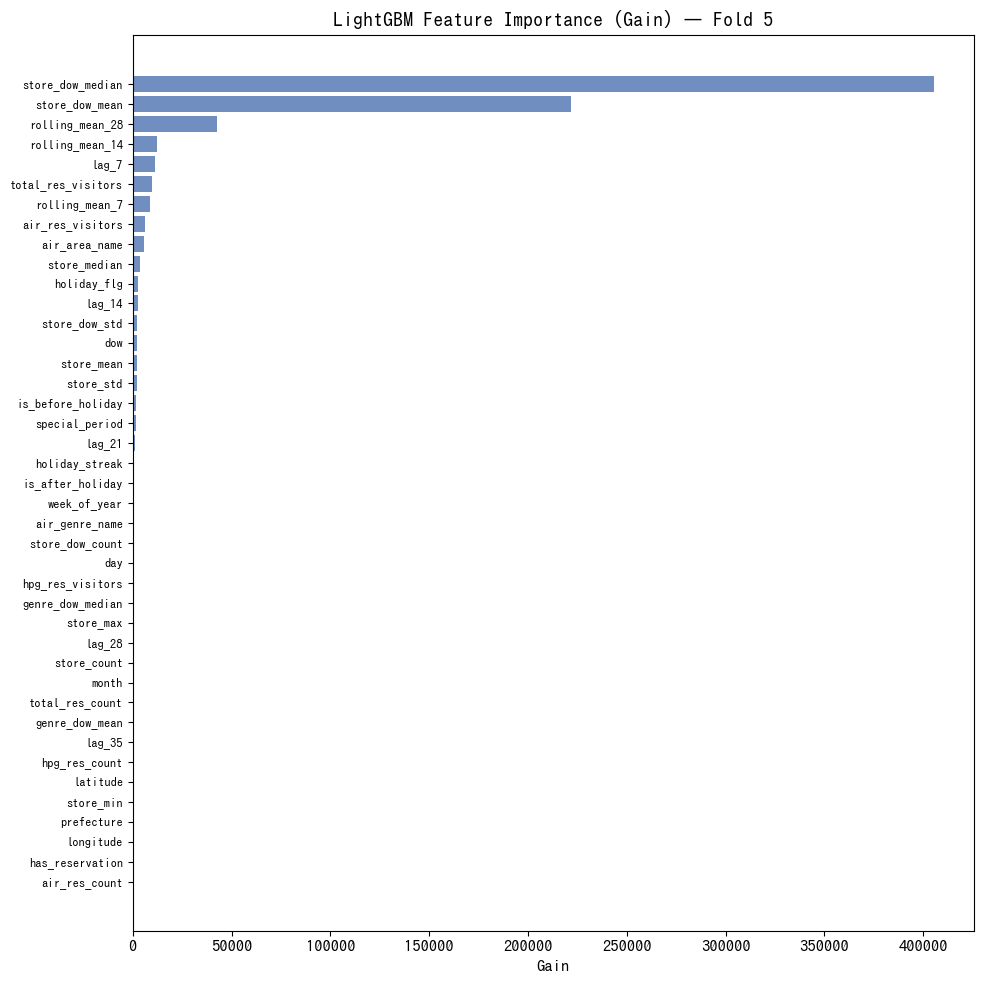

=== 特徴量重要度の考察 ===
Top 5:
  store_dow_median: 405396
  store_dow_mean: 221885
  rolling_mean_28: 42745
  rolling_mean_14: 12127
  lag_7: 11244

→ EDAの予測通り、store-level統計量とDOW関連が上位
→ ラグ特徴量もテスト期間ではNaNが多いが、学習時の精度向上に貢献


In [11]:
# ── Feature Importance (LightGBM のみ — 最も高速なモデルで確認) ──
# 最後のfoldのモデルで特徴量重要度を確認

val_start_ts = pd.Timestamp(val_folds[-1][0])
val_end_ts = pd.Timestamp(val_folds[-1][1])
train_data = air_visit[air_visit['visit_date'] < val_start_ts]
val_data = air_visit[(air_visit['visit_date'] >= val_start_ts) & (air_visit['visit_date'] <= val_end_ts)]

train_feat = build_features(train_data, train_data, air_store, date_feat, air_res_agg, hpg_res_agg, True)
train_feat = train_feat.dropna(subset=['visitors'])
val_feat = build_features(train_data, val_data, air_store, date_feat, air_res_agg, hpg_res_agg, True)
val_feat = val_feat.dropna(subset=['visitors'])

X_tr = train_feat[ALL_FEATURES].copy()
X_v = val_feat[ALL_FEATURES].copy()

lgb_model = train_lgbm(X_tr, np.log1p(train_feat['visitors']), X_v, np.log1p(val_feat['visitors']), CATEGORICAL_FEATURES)

# Plot feature importance
importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(importance)), importance['importance'], color='#4C72B0', alpha=0.8)
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance['feature'], fontsize=9)
ax.set_title('LightGBM Feature Importance (Gain) — Fold 5')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print('=== 特徴量重要度の考察 ===')
top5 = importance.nlargest(5, 'importance')
print('Top 5:')
for _, row in top5.iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.0f}')
print('\n→ EDAの予測通り、store-level統計量とDOW関連が上位')
print('→ ラグ特徴量もテスト期間ではNaNが多いが、学習時の精度向上に貢献')

---
## 6. ハイパーパラメータ調整（Optuna）

### 調整方針
- **LightGBMのみ**をOptunaで最適化（最速 → 探索回数を稼げる）
- XGBoost/CatBoostは後でアンサンブル時に調整の余地を残す
- 探索空間はデフォルトパラメータ周辺に設定（大きく外さない）
- **CVスコア（5-fold平均）** を最適化対象とする
- 試行回数: 30回（速度と精度のバランス）

In [12]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optuna objective: 5-fold CV mean RMSLE for LightGBM."""
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'verbose': -1,
        'seed': 42,
    }
    
    fold_scores = []
    for val_start, val_end in val_folds:
        val_start_ts, val_end_ts = pd.Timestamp(val_start), pd.Timestamp(val_end)
        
        train_data = air_visit[air_visit['visit_date'] < val_start_ts]
        val_data = air_visit[(air_visit['visit_date'] >= val_start_ts) & 
                              (air_visit['visit_date'] <= val_end_ts)]
        
        if len(val_data) == 0 or len(train_data) == 0:
            continue
        
        train_feat = build_features(train_data, train_data, air_store, date_feat, 
                                     air_res_agg, hpg_res_agg, True)
        val_feat = build_features(train_data, val_data, air_store, date_feat, 
                                   air_res_agg, hpg_res_agg, True)
        
        train_feat = train_feat.dropna(subset=['visitors'])
        val_feat = val_feat.dropna(subset=['visitors'])
        
        if len(train_feat) == 0 or len(val_feat) == 0:
            continue
        
        X_tr = train_feat[ALL_FEATURES].copy()
        X_v = val_feat[ALL_FEATURES].copy()
        
        # Unify categories
        X_tr, X_v = unify_categories(X_tr, X_v, CATEGORICAL_FEATURES)
        
        y_tr = np.log1p(train_feat['visitors'])
        y_v_raw = val_feat['visitors']
        
        train_set = lgb.Dataset(X_tr, y_tr, categorical_feature=CATEGORICAL_FEATURES)
        val_set = lgb.Dataset(X_v, np.log1p(y_v_raw), categorical_feature=CATEGORICAL_FEATURES, reference=train_set)
        
        model = lgb.train(params, train_set, num_boost_round=1000,
                          valid_sets=[val_set],
                          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        
        # Predict using the unified X_v (same categories as training)
        y_pred = np.expm1(model.predict(X_v))
        y_pred = np.maximum(y_pred, 0)
        
        score = rmsle(y_v_raw.values, y_pred)
        fold_scores.append(score)
    
    if len(fold_scores) == 0:
        return float('inf')
    return np.mean(fold_scores)

# Run Optuna
print('Running Optuna (30 trials)...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f'\nBest trial:')
print(f'  Score (Mean RMSLE): {study.best_value:.4f}')
print(f'  Params:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

best_lgbm_params = study.best_params

Running Optuna (30 trials)...


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[97]	valid_0's rmse: 0.5835


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[55]	valid_0's rmse: 0.592925


...

Early stopping, best iteration is:
[168]	valid_0's rmse: 0.548526


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[158]	valid_0's rmse: 0.581094


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[113]	valid_0's rmse: 0.550798

Best trial:
  Score (Mean RMSLE): 0.5698
  Params:
    learning_rate: 0.03564015491211912
    num_leaves: 24
    max_depth: 10
    min_child_samples: 19
    feature_fraction: 0.7166073301368286
    bagging_fraction: 0.770599250687045
    bagging_freq: 2
    lambda_l1: 9.854392303204632
    lambda_l2: 0.004247784656416567


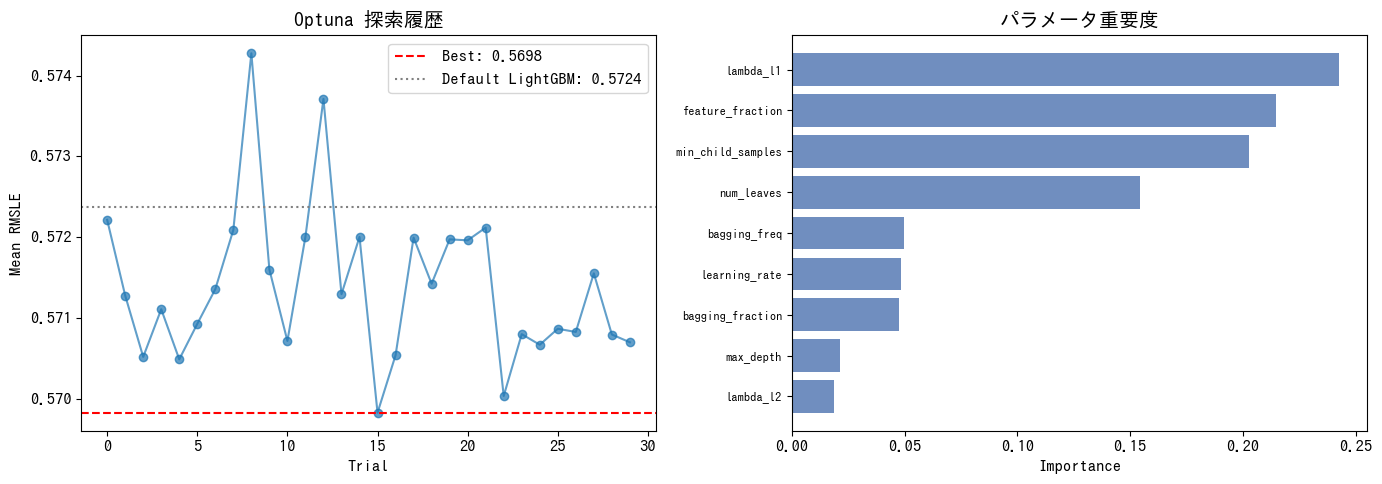


Default LightGBM: 0.5724
Tuned LightGBM:   0.5698
Improvement:      +0.0025 (+0.44%)


In [13]:
# ── Optuna探索の可視化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values, 'o-', alpha=0.7)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
if results:
    axes[0].axhline(results['LightGBM']['mean'], color='gray', linestyle=':', 
                    label=f'Default LightGBM: {results["LightGBM"]["mean"]:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Mean RMSLE')
axes[0].set_title('Optuna 探索履歴')
axes[0].legend()

# Parameter importance
param_importance = optuna.importance.get_param_importances(study)
params_sorted = sorted(param_importance.items(), key=lambda x: x[1], reverse=True)
param_names = [p[0] for p in params_sorted]
param_values = [p[1] for p in params_sorted]

axes[1].barh(range(len(param_names)), param_values, color='#4C72B0', alpha=0.8)
axes[1].set_yticks(range(len(param_names)))
axes[1].set_yticklabels(param_names, fontsize=9)
axes[1].set_title('パラメータ重要度')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Compare default vs tuned
if results:
    improvement = results['LightGBM']['mean'] - study.best_value
    print(f'\nDefault LightGBM: {results["LightGBM"]["mean"]:.4f}')
    print(f'Tuned LightGBM:   {study.best_value:.4f}')
    print(f'Improvement:      {improvement:+.4f} ({improvement/results["LightGBM"]["mean"]*100:+.2f}%)')

---
## 7. アンサンブル → 最終モデル → Submission

### アンサンブル戦略
- **単純な重み付き平均**: モデル多様性を活かす最もシンプルな方法
- 重みは CV スコアの逆数に基づいて設定（良いモデルに高い重み）
- log1p空間で平均 → expm1で逆変換

### 最終学習
- 全学習データ（テスト期間直前まで）で再学習
- Optunaで最適化したLightGBMパラメータを使用
- XGBoost/CatBoostはデフォルトパラメータ（Sec 5で検証済み）

In [14]:
# ── 7a. アンサンブルの重み計算 ──
# CVスコアの逆数で重み付け
print('=== Ensemble Weight Calculation ===\n')

inverse_scores = {name: 1.0 / r['mean'] for name, r in results.items()}
total_inv = sum(inverse_scores.values())
weights = {name: inv / total_inv for name, inv in inverse_scores.items()}

for name, w in weights.items():
    print(f'  {name:<15s}: weight = {w:.3f}  (CV = {results[name]["mean"]:.4f})')

print(f'\n→ スコアが良いモデルほど高い重みを割り当て')

=== Ensemble Weight Calculation ===

  LightGBM       : weight = 0.339  (CV = 0.5724)
  XGBoost        : weight = 0.332  (CV = 0.5848)
  CatBoost       : weight = 0.329  (CV = 0.5913)

→ スコアが良いモデルほど高い重みを割り当て


In [15]:
# ── 7b. 最終モデルの学習 & テスト予測 ──
print('=== Final Model Training ===\n')

# Use ALL training data
full_train = air_visit.copy()
test_df = submission[['air_store_id', 'visit_date']].copy()

# Build features for test set
test_feat = build_features(full_train, test_df, air_store, date_feat, 
                           air_res_agg, hpg_res_agg, compute_target=False)

# Build features for full training
train_feat_full = build_features(full_train, full_train, air_store, date_feat, 
                                  air_res_agg, hpg_res_agg, compute_target=True)
train_feat_full = train_feat_full.dropna(subset=['visitors'])

X_train_full = train_feat_full[ALL_FEATURES]
y_train_full = np.log1p(train_feat_full['visitors'])
X_test = test_feat[ALL_FEATURES]

print(f'Training samples: {len(X_train_full):,}')
print(f'Test samples: {len(X_test):,}')
print(f'Missing values in test features:')
missing_pct = X_test.isnull().mean().sort_values(ascending=False)
for col in missing_pct[missing_pct > 0].index[:10]:
    print(f'  {col}: {missing_pct[col]*100:.1f}%')

# ── Train each model on full data ──
predictions = {}

# 1. LightGBM (tuned)
print('\n--- LightGBM (Optuna-tuned) ---')
X_tr_lgb = X_train_full.copy()
X_te_lgb = X_test.copy()
for col in CATEGORICAL_FEATURES:
    X_tr_lgb[col] = X_tr_lgb[col].astype('category')
    X_te_lgb[col] = X_te_lgb[col].astype('category')

lgb_params = {**best_lgbm_params, 'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'seed': 42}
train_set = lgb.Dataset(X_tr_lgb, y_train_full, categorical_feature=CATEGORICAL_FEATURES)
final_lgbm = lgb.train(lgb_params, train_set, num_boost_round=500)
predictions['LightGBM'] = final_lgbm.predict(X_te_lgb)
print(f'  Trained. Predictions shape: {predictions["LightGBM"].shape}')

# 2. XGBoost (default)
print('\n--- XGBoost ---')
X_tr_xgb = encode_categoricals(X_train_full, ALL_FEATURES, CATEGORICAL_FEATURES, label_encoders)
X_te_xgb = encode_categoricals(X_test, ALL_FEATURES, CATEGORICAL_FEATURES, label_encoders)
dtrain = xgb.DMatrix(X_tr_xgb, y_train_full)
dtest = xgb.DMatrix(X_te_xgb)
xgb_params = {
    'objective': 'reg:squarederror', 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'lambda': 1.0, 'alpha': 0.1, 'seed': 42, 'verbosity': 0,
}
final_xgb = xgb.train(xgb_params, dtrain, num_boost_round=500)
predictions['XGBoost'] = final_xgb.predict(dtest)
print(f'  Trained. Predictions shape: {predictions["XGBoost"].shape}')

# 3. CatBoost (default)
print('\n--- CatBoost ---')
X_tr_cb = X_train_full.copy()
X_te_cb = X_test.copy()
for col in CATEGORICAL_FEATURES:
    X_tr_cb[col] = X_tr_cb[col].fillna('unknown').astype(str)
    X_te_cb[col] = X_te_cb[col].fillna('unknown').astype(str)
cat_indices = [list(X_tr_cb.columns).index(c) for c in CATEGORICAL_FEATURES]
final_cb = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, 
                              l2_leaf_reg=3, random_seed=42, verbose=0, cat_features=cat_indices)
final_cb.fit(X_tr_cb, y_train_full, verbose=0)
predictions['CatBoost'] = final_cb.predict(X_te_cb)
print(f'  Trained. Predictions shape: {predictions["CatBoost"].shape}')

print('\nAll models trained successfully.')

=== Final Model Training ===



Training samples: 252,108
Test samples: 32,019
Missing values in test features:
  lag_14: 100.0%
  lag_35: 100.0%
  lag_28: 100.0%
  lag_21: 100.0%
  lag_7: 100.0%
  hpg_res_count: 99.0%
  hpg_res_visitors: 99.0%
  rolling_mean_7: 97.4%
  rolling_mean_14: 97.4%
  rolling_mean_28: 97.4%

--- LightGBM (Optuna-tuned) ---


  Trained. Predictions shape: (32019,)

--- XGBoost ---


  Trained. Predictions shape: (32019,)

--- CatBoost ---


  Trained. Predictions shape: (32019,)

All models trained successfully.


=== Submission Sanity Check ===
Shape: (32019, 2)
Visitors range: 1.0 ~ 92.8
Mean: 12.3
Median: 10.6
NaN count: 0


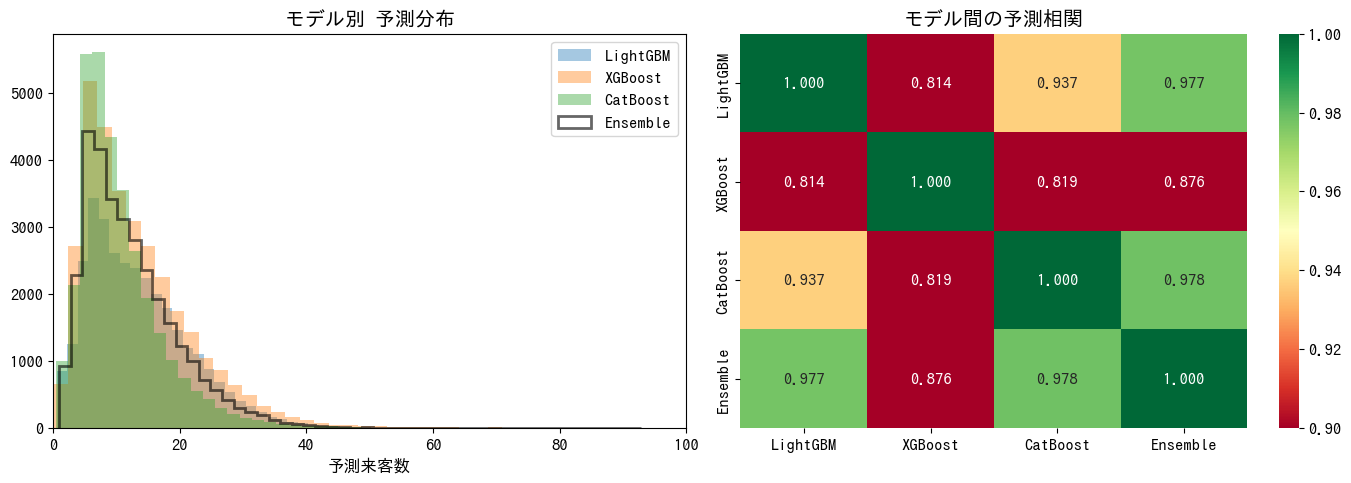


→ 相関が1.0に近い場合、アンサンブル効果は限定的
→ 相関が低いほど、アンサンブルによる分散削減効果が大きい


In [16]:
# ── 7c. アンサンブル & Submission生成 ──

# Weighted ensemble in log1p space
ensemble_log = np.zeros(len(X_test))
for name, pred_log in predictions.items():
    ensemble_log += weights[name] * pred_log

# Convert back to original scale
ensemble_pred = np.expm1(ensemble_log)
ensemble_pred = np.maximum(ensemble_pred, 1)  # 最低1人（0人予測は非現実的）

# Create submission
sub = submission[['id']].copy()
sub['visitors'] = ensemble_pred

# Sanity check
print('=== Submission Sanity Check ===')
print(f'Shape: {sub.shape}')
print(f'Visitors range: {sub["visitors"].min():.1f} ~ {sub["visitors"].max():.1f}')
print(f'Mean: {sub["visitors"].mean():.1f}')
print(f'Median: {sub["visitors"].median():.1f}')
print(f'NaN count: {sub["visitors"].isna().sum()}')

# Compare individual model predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predictions
for name, pred_log in predictions.items():
    pred = np.expm1(pred_log)
    axes[0].hist(pred, bins=50, alpha=0.4, label=name)
axes[0].hist(ensemble_pred, bins=50, alpha=0.6, label='Ensemble', color='black', histtype='step', linewidth=2)
axes[0].set_title('モデル別 予測分布')
axes[0].set_xlabel('予測来客数')
axes[0].legend()
axes[0].set_xlim(0, 100)

# Model correlation
pred_df = pd.DataFrame({name: np.expm1(pred) for name, pred in predictions.items()})
pred_df['Ensemble'] = ensemble_pred
corr = pred_df.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.9, vmax=1.0, ax=axes[1])
axes[1].set_title('モデル間の予測相関')

plt.tight_layout()
plt.show()

print('\n→ 相関が1.0に近い場合、アンサンブル効果は限定的')
print('→ 相関が低いほど、アンサンブルによる分散削減効果が大きい')

In [17]:
# ── 7d. Submission保存 ──
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sub_path = OUTPUT_DIR / 'submission_ensemble_20260308.csv'
sub.to_csv(sub_path, index=False)
print(f'Submission saved to: {sub_path}')
print(f'Shape: {sub.shape}')
print(sub.head(10))

Submission saved to: ../output/submission_ensemble_20260308.csv
Shape: (32019, 2)
                                id   visitors
0  air_00a91d42b08b08d9_2017-04-23   1.911713
1  air_00a91d42b08b08d9_2017-04-24  10.784010
2  air_00a91d42b08b08d9_2017-04-25  12.754589
3  air_00a91d42b08b08d9_2017-04-26  14.128650
4  air_00a91d42b08b08d9_2017-04-27  16.009675
5  air_00a91d42b08b08d9_2017-04-28  18.251621
6  air_00a91d42b08b08d9_2017-04-29   5.437979
7  air_00a91d42b08b08d9_2017-04-30   1.218605
8  air_00a91d42b08b08d9_2017-05-01  17.270806
9  air_00a91d42b08b08d9_2017-05-02  23.325068


---
## 8. まとめ: 設計判断の記録

### モデル選定の根拠（結果ではなくプロセス）

| ステップ | 判断 | 根拠 |
|---------|------|------|
| 1. モデルファミリー | GBDTを選択 | パネルデータ×カテゴリカル特徴量×外部データ → テーブル系が最適 (Sec 2a) |
| 2. 候補絞り込み | LightGBM/XGBoost/CatBoostの3つ | それぞれ異なる強みを持つ → アンサンブルの多様性 (Sec 2b) |
| 3. RF除外 | ブースティング優先 | lag/rolling特徴量+多段交互作用 → 逐次残差学習が効率的 (Sec 2c) |
| 4. 特徴量設計 | EDAの12セクションから導出 | 各特徴量にEDA根拠を紐付け (Sec 4) |
| 5. バリデーション | 5-fold TimeSeriesSplit (39日窓) | テスト期間と同じ長さ、GW含むfold必須 (EDA Sec 11) |
| 6. ベースライン | store × DOW median | 曜日が最大の駆動要因 (EDA Sec 5) |
| 7. パラメータ調整 | OptunaでLightGBMのみ | 最速モデルで探索回数を最大化 (Sec 6) |
| 8. アンサンブル | CVスコア逆数の重み付き平均 | シンプルで安定 (Sec 7) |

### 残課題・改善候補
- [ ] XGBoost/CatBoostもOptuna最適化
- [ ] スタッキング（2段目モデル）の検討
- [ ] GW期間のみ別モデルで予測する戦略
- [ ] 天気データの追加（11th place solutionで有効性確認済み）
- [ ] ニューラルネットワーク（MLP/TabNet）の追加